## Exercício 1 - Gerador Linear Congruente

In [2]:
# Parâmetros do Gerador
a = 11
c = 7
m = 32
X0 = 5

# Lista para armazenar os valores gerados
X = [X0]

# a) Gerar os 10 primeiros números
for i in range(10):
  X_next = (a * X[-1] + c) % m # Fórmula do LCG
  X.append(X_next)

print("10 primeiros valores:", X[1:]) # Ignora X0

# b) Determinar o período
# Gerar até repetir o valor inicial
valores = []
x = X0

while x not in valores:
  valores.append(x)
  x = (a * x + c) % m

periodo = len(valores)
print("Período do gerador:", periodo)

# c) Verificar período máximo
# Um LCG tem período máximo m se satizfaz certas condições teóricas
if periodo == m:
  print("O gerador tem período máximo.")
else:
  print("O gerador NÃO tem período máximo.")

10 primeiros valores: [30, 17, 2, 29, 6, 9, 10, 21, 14, 1]
Período do gerador: 16
O gerador NÃO tem período máximo.


## Exercício 2 - Distribuição de Poisson


In [3]:
import math
from scipy.stats import poisson

lambda1 = 4 # média por hora

# a) P(X = 6)
p_a = poisson.pmf(6, lambda1)
print("P(X=6):", p_a)

# b) P(X <= 2)
p_b = poisson.cdf(2, lambda1)
print("P(X<=2):", p_b)

# c) Mais de 5 falhas em 2 horas
# lambda dobra (tempo dobra)
lambda_2h = 8

p_c = 1 - poisson.cdf(5, lambda_2h)
print("P(X>5 em 2h):", p_c)

# d) Média e variância
media = lambda1
variancia = lambda1

print("Média:", media)
print("Variância:", variancia)

P(X=6): 0.10419563456702102
P(X<=2): 0.23810330555354436
P(X>5 em 2h): 0.8087639379203747
Média: 4
Variância: 4


## Exercício 3 - Distribuição Binomial

In [4]:
from scipy.stats import binom

n = 20   # número de pacotes
p = 0.08 # probabilidade de erro

# a) P(X = 3)
p_a = binom.pmf(3, n, p)
print("P(X=3):", p_a)

# b) P(X <= 2)
p_b = binom.cdf(2, n, p)
print("P(X<=2):", p_b)

# c) P(X > 5)
p_c = 1 - binom.cdf(5, n, p)
print("P(X>5):", p_c)

# d) Média e variância
media = n * p
variancia = n * p * (1-p)

print("Média:", media)
print("Variância:", variancia)

P(X=3): 0.14143857663883486
P(X<=2): 0.7879462459747022
P(X>5): 0.0037994868343930177
Média: 1.6
Variância: 1.4720000000000002


## Exercício 4 - Distribuição Geométrica

In [5]:
import numpy as np

p = 0.3

# a) Simulação (n = múmero de falhas antes do sucesso)
def gerar_geom(p):
  n = 0
  while np.random.rand() > p:
    n += 1
  return n

# Gerar 10 amostras
amostras = [gerar_geom(p) for _ in range(10)]
print("Amostras geométricas:", amostras)

# b) Primeiro sucesso na 4° tentativa
# n falhas antes -> n = 3
p_b = (1 - p)**3 * p
print("P(1° sucesso na 4° tentativa):", p_b)

# c) Mais de 6 tentativas -> mais de 5 falhas
p_c = (1 - p)**6
print("P(mais de 6 tentativas):", p_c)

# d) Média e variância
media = (1 - p) / p
variancia = (1 - p) / (p**2)

print("Média:", media)
print("Variância:", variancia)

Amostras geométricas: [3, 0, 3, 3, 6, 2, 1, 0, 3, 2]
P(1° sucesso na 4° tentativa): 0.10289999999999998
P(mais de 6 tentativas): 0.11764899999999996
Média: 2.3333333333333335
Variância: 7.777777777777778


## Exercício 5 - Método da Inversa

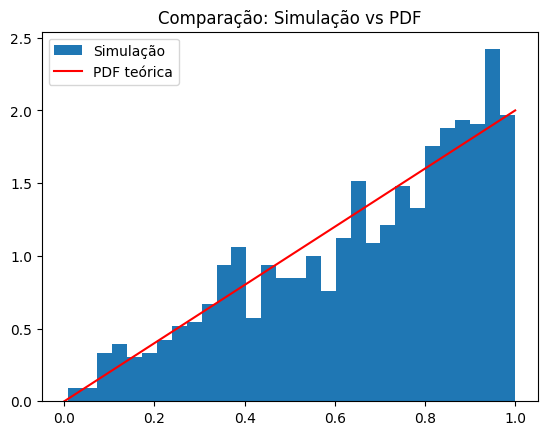

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# a) Verificação (comentário)
"""
Integral de 2x de 0 a 1 = 1 -> é valida como PDF
"""

# b) CDF
"""
F(x) = ∫0 até x de 2t dt = x²
"""

# c) Inversa:
"""
u = x² -> x = sqrt(u)
"""

# Função geradora usando inversa
def gerar_amostras(n):
  u = np.random.rand(n)  # uniforme(0,1)
  x = np.sqrt(u)         # transformação inversa
  return x

# e) Gerar amostras e comparar
amostras = gerar_amostras(1000)

# Histograma
plt.hist(amostras, bins=30, density=True, label="Simulação")

# PDF teórica
x = np.linspace(0, 1, 100)
pdf = 2 * x
plt.plot(x, pdf, 'r', label="PDF teórica")

plt.legend()
plt.title("Comparação: Simulação vs PDF")
plt.show()